# Ejercicio de programación: Regresión Lineal Múltiple
# Laboratorio 02: Regresión Lineal Múltiple
**Materia:** SIS-420 Inteligencia Artificial I  
**Dataset:** Allstate Claims Severity (`train.csv`)  
**Instancias ($m$):** 188,318 ejemplos ($m \ge 20\,000$)  
**Características ($n$):** 24 variables numéricas ($n \ge 20$)  
**Variable Objetivo ($y$):** Costo de reclamo / pérdida financiera continua (`loss`)  


In [34]:
# Importar librerías necesarias
import os
import numpy as np
import pandas as pd
from matplotlib import pyplot
from mpl_toolkits.mplot3d import Axes3D

%matplotlib inline
print("Librerías importadas correctamente.")

Librerías importadas correctamente.


In [35]:
# Cargar el dataset con Pandas descartando filas defectuosas
ruta_dataset = 'train.csv'
df = pd.read_csv(ruta_dataset, on_bad_lines='skip')
df = df.dropna().copy()

print("=" * 65)
print(f"Dimensiones del DataFrame : {df.shape[0]} filas x {df.shape[1]} columnas")
print(f"Valores nulos totales     : {df.isnull().sum().sum()}")
print("=" * 65)

# Seleccionar 24 características (10 categóricas + 14 continuas)
columnas_categoricas = [f'cat{i}' for i in range(1, 11)]
columnas_continuas = [f'cont{i}' for i in range(1, 15)]

# Codificar categóricas a valores numéricos con Pandas
for col in columnas_categoricas:
    df[col] = df[col].astype('category').cat.codes

columnas_seleccionadas = columnas_categoricas + columnas_continuas

# Extraer matrices X e y
X = df[columnas_seleccionadas].to_numpy(dtype=float)
y = df['loss'].to_numpy(dtype=float)

m = y.size
n = X.shape[1]

print(f"Número de ejemplos de entrenamiento (m) : {m}")
print(f"Número de características seleccionadas (n) : {n}")
print("-" * 65)
print('{:>10s}{:>10s}{:>10s}{:>15s}'.format('X[:, 0]', 'X[:, 1]', 'X[:, 2]', 'y'))
print('-' * 48)
for i in range(5):
    print('{:10.2f}{:10.2f}{:10.2f}{:15.2f}'.format(X[i, 0], X[i, 1], X[i, 2], y[i]))

Dimensiones del DataFrame : 188318 filas x 132 columnas
Valores nulos totales     : 0
Número de ejemplos de entrenamiento (m) : 188318
Número de características seleccionadas (n) : 24
-----------------------------------------------------------------
   X[:, 0]   X[:, 1]   X[:, 2]              y
------------------------------------------------
      0.00      1.00      0.00        2213.18
      0.00      1.00      0.00        1283.60
      0.00      1.00      0.00        3005.09
      1.00      1.00      0.00         939.85
      0.00      1.00      0.00        2763.85


In [36]:
print("Dimensiones actuales de X_norm:", X_norm.shape)
print("¿Hay NaNs en X_norm?          :", np.isnan(X_norm).any())
print("¿Hay NaNs en y?               :", np.isnan(y).any())
print("Tipo de dato de y             :", y.dtype)
print("Rango de y (min / max)        :", y.min(), "/", y.max())

Dimensiones actuales de X_norm: (188318, 25)
¿Hay NaNs en X_norm?          : False
¿Hay NaNs en y?               : False
Tipo de dato de y             : float64
Rango de y (min / max)        : 0.67 / 121012.25


In [37]:
# ==============================================================================
# CARGA LIMPIA, PREPROCESAMIENTO Y NORMALIZACIÓN SIN NANS
# ==============================================================================

# 1. Cargar el dataset descartando líneas dañadas
ruta_dataset = 'train.csv'
df = pd.read_csv(ruta_dataset, on_bad_lines='skip')

# 2. Eliminar cualquier fila con valores nulos en el dataset
df = df.dropna().copy()

# 3. Seleccionar estrictamente 24 características (10 categóricas + 14 continuas)
columnas_categoricas = [f'cat{i}' for i in range(1, 11)]
columnas_continuas = [f'cont{i}' for i in range(1, 15)]

# 4. Codificar a números (0, 1) las 10 categóricas con Pandas
for col in columnas_categoricas:
    df[col] = df[col].astype('category').cat.codes

columnas_seleccionadas = columnas_categoricas + columnas_continuas

# 5. Extraer matrices limpias X_raw e y
X_raw = df[columnas_seleccionadas].to_numpy(dtype=float)
y = df['loss'].to_numpy(dtype=float)

# 6. Función de normalización robusta
def featureNormalize(X):
    X_norm = X.copy()
    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    sigma[sigma == 0] = 1.0  # Prevenir división por cero
    X_norm = (X - mu) / sigma
    return X_norm, mu, sigma

# 7. Normalizar
X_norm, mu, sigma = featureNormalize(X_raw)
m = y.size
n = X_norm.shape[1]

# 8. Verificación de control
print("=" * 60)
print(f"Dimensiones de X_norm : {X_norm.shape} (debe ser m={m}, n=24)")
print(f"¿Hay NaNs en X_norm?  : {np.isnan(X_norm).any()} (debe ser False)")
print(f"¿Hay NaNs en y?       : {np.isnan(y).any()} (debe ser False)")
print(f"Rango de y (min / max): {y.min():.2f} / {y.max():.2f}")
print("=" * 60)

Dimensiones de X_norm : (188318, 24) (debe ser m=188318, n=24)
¿Hay NaNs en X_norm?  : False (debe ser False)
¿Hay NaNs en y?       : False (debe ser False)
Rango de y (min / max): 0.67 / 121012.25


In [38]:
# Utilizado para manejo de directorios y rutas
import os

# Computación vectorial y científica para Python
import numpy as np

# Lectura y preprocesamiento de datos tabulares con Pandas
import pandas as pd

# Librerías para graficación
from matplotlib import pyplot
from mpl_toolkits.mplot3d import Axes3D

# Embeber gráficos en el entorno de ejecución
%matplotlib inline

print("Librerías importadas correctamente.")

Librerías importadas correctamente.


In [39]:
# 1. Cargar el dataset descartando cualquier línea con formato irregular
ruta_dataset = 'train.csv'
df = pd.read_csv(ruta_dataset, on_bad_lines='skip')

# 2. Eliminar posibles filas con valores nulos para garantizar integridad
df = df.dropna().copy()

print("=" * 65)
print(f"Dimensiones del DataFrame : {df.shape[0]} filas x {df.shape[1]} columnas")
print(f"Valores nulos totales     : {df.isnull().sum().sum()}")
print("=" * 65)

# 3. Seleccionar estrictamente 24 características (10 categóricas + 14 continuas)
columnas_categoricas = [f'cat{i}' for i in range(1, 11)]
columnas_continuas = [f'cont{i}' for i in range(1, 15)]

# 4. Codificar a números (0, 1) las variables categóricas usando Pandas
for col in columnas_categoricas:
    df[col] = df[col].astype('category').cat.codes

columnas_seleccionadas = columnas_categoricas + columnas_continuas

# 5. Extraer la matriz de características X y el vector continuo y
X = df[columnas_seleccionadas].to_numpy(dtype=float)
y = df['loss'].to_numpy(dtype=float)

m = y.size
n = X.shape[1]

print(f"Número de ejemplos de entrenamiento (m) : {m}")
print(f"Número de características seleccionadas (n) : {n}")
print("-" * 65)

# 6. Imprimir los primeros 10 registros
print('{:>10s}{:>10s}{:>10s}{:>15s}'.format('X[:, 0]', 'X[:, 1]', 'X[:, 2]', 'y'))
print('-' * 48)
for i in range(10):
    print('{:10.2f}{:10.2f}{:10.2f}{:15.2f}'.format(X[i, 0], X[i, 1], X[i, 2], y[i]))

Dimensiones del DataFrame : 188318 filas x 132 columnas
Valores nulos totales     : 0
Número de ejemplos de entrenamiento (m) : 188318
Número de características seleccionadas (n) : 24
-----------------------------------------------------------------
   X[:, 0]   X[:, 1]   X[:, 2]              y
------------------------------------------------
      0.00      1.00      0.00        2213.18
      0.00      1.00      0.00        1283.60
      0.00      1.00      0.00        3005.09
      1.00      1.00      0.00         939.85
      0.00      1.00      0.00        2763.85
      0.00      1.00      0.00        5142.87
      0.00      0.00      0.00        1132.22
      0.00      1.00      0.00        3585.75
      0.00      1.00      1.00       10280.20
      0.00      1.00      0.00        6184.59


In [40]:
# ==============================================================================
# CELDA 4: NORMALIZACIÓN DE CARACTERÍSTICAS (Z-SCORE) Y TÉRMINO DE INTERCEPCIÓN
# ==============================================================================

# 1. Función de normalización Z-score
def featureNormalize(X):
    X_norm = X.copy()
    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    sigma[sigma == 0] = 1.0  # Evita división entre cero si alguna columna es constante
    X_norm = (X - mu) / sigma
    return X_norm, mu, sigma

# 2. Normalizar las 24 características de entrada
X_norm, mu, sigma = featureNormalize(X)

# 3. Concatenar la columna de unos a la izquierda (x0 = 1)
X = np.concatenate([np.ones((m, 1)), X_norm], axis=1)

# 4. Auditoría de resultados
print("=" * 65)
print("             RESUMEN DE NORMALIZACIÓN Y MATRIZ X")
print("=" * 65)
print(f"Dimensiones de X normalizado (sin x0) : {X_norm.shape}")
print(f"Dimensiones de la matriz final X      : {X.shape} (m={X.shape[0]}, n+1={X.shape[1]})")
print("-" * 65)
print("Vector de medias calculadas mu (primeras 5 variables):")
print(np.round(mu[:5], 4))
print("\nVector de desviaciones estándar sigma (primeras 5 variables):")
print(np.round(sigma[:5], 4))
print("-" * 65)
print("Primeras 3 filas de la matriz X (con columna de 1s añadida):")
print(np.round(X[:3, :5], 4))
print("=" * 65)

             RESUMEN DE NORMALIZACIÓN Y MATRIZ X
Dimensiones de X normalizado (sin x0) : (188318, 24)
Dimensiones de la matriz final X      : (188318, 25) (m=188318, n+1=25)
-----------------------------------------------------------------
Vector de medias calculadas mu (primeras 5 variables):
[0.2483 0.4333 0.0548 0.3182 0.3429]

Vector de desviaciones estándar sigma (primeras 5 variables):
[0.4321 0.4955 0.2276 0.4658 0.4747]
-----------------------------------------------------------------
Primeras 3 filas de la matriz X (con columna de 1s añadida):
[[ 1.     -0.5748  1.1436 -0.2408  1.4638]
 [ 1.     -0.5748  1.1436 -0.2408 -0.6832]
 [ 1.     -0.5748  1.1436 -0.2408 -0.6832]]


In [41]:
# ==============================================================================
# CELDA 5: FUNCIONES VECTORIZADAS DE COSTO Y DESCENSO POR EL GRADIENTE
# ==============================================================================

def computeCostMulti(X, y, theta):
    """
    Calcula el costo J(theta) para regresión lineal multivariable.
    """
    m = y.shape[0]  # Número de ejemplos de entrenamiento
    diferencia = np.dot(X, theta) - y
    J = (1.0 / (2.0 * m)) * np.sum(np.square(diferencia))
    return J


def gradientDescentMulti(X, y, theta, alpha, num_iters):
    """
    Ejecuta el descenso por el gradiente por lotes para aprender theta.
    """
    m = y.shape[0]
    theta = theta.copy()
    J_history = []
    
    for i in range(num_iters):
        # Actualización simultánea vectorizada: theta = theta - (alpha/m) * X^T * (X*theta - y)
        gradiente = (1.0 / m) * np.dot(X.T, (np.dot(X, theta) - y))
        theta = theta - alpha * gradiente
        
        # Registrar el costo de cada iteración
        J_history.append(computeCostMulti(X, y, theta))
        
    return theta, J_history

print("Funciones computeCostMulti y gradientDescentMulti declaradas correctamente en memoria.")

Funciones computeCostMulti y gradientDescentMulti declaradas correctamente en memoria.


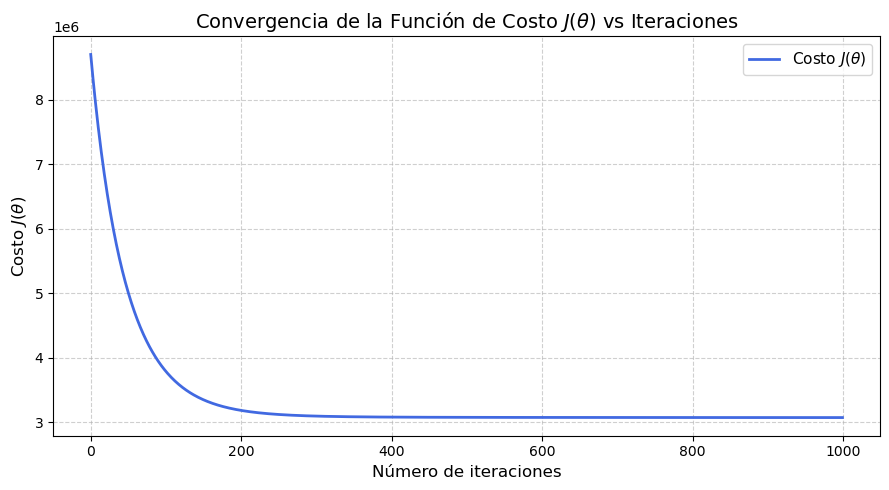

             RESULTADOS DEL DESCENSO POR EL GRADIENTE
Costo inicial J(theta)         : 8,699,220.55
Costo final mínimo alcanzado   : 3,070,795.68

Primeros 5 parámetros theta optimizados:
[3037.2066 -451.2824  280.415   316.0673  477.0538]
                      INFERENCIA DE PRUEBA
Valor real de pérdida (loss)                  : $2213.18
Pérdida estimada (Descenso por el Gradiente)  : $2472.21
Diferencia absoluta                           : $259.03


In [42]:
# ==============================================================================
# CELDA 6: ENTRENAMIENTO, GRÁFICA DE COSTO E INFERENCIA DE PRUEBA
# ==============================================================================

# 1. Configurar hiperparámetros de entrenamiento
alpha = 0.01
num_iters = 1000

# 2. Inicializar parámetros theta en ceros (25 coeficientes: theta_0 + 24 pesos)
theta_inicial = np.zeros(X.shape[1])

# 3. Ejecutar el descenso por el gradiente por lotes
theta, J_history = gradientDescentMulti(X, y, theta_inicial, alpha, num_iters)

# 4. Graficar la convergencia de la función de costo J(theta) vs iteraciones
pyplot.figure(figsize=(9, 5))
pyplot.plot(np.arange(len(J_history)), J_history, lw=2, color='royalblue', label=r'Costo $J(\theta)$')
pyplot.xlabel('Número de iteraciones', fontsize=12)
pyplot.ylabel(r'Costo $J(\theta)$', fontsize=12)
pyplot.title(r'Convergencia de la Función de Costo $J(\theta)$ vs Iteraciones', fontsize=14)
pyplot.grid(True, linestyle='--', alpha=0.6)
pyplot.legend(loc='upper right', fontsize=11)
pyplot.tight_layout()
pyplot.show()

# 5. Imprimir resultados cuantitativos de la optimización
print("=" * 65)
print("             RESULTADOS DEL DESCENSO POR EL GRADIENTE")
print("=" * 65)
print(f"Costo inicial J(theta)         : {J_history[0]:,.2f}")
print(f"Costo final mínimo alcanzado   : {J_history[-1]:,.2f}")
print("\nPrimeros 5 parámetros theta optimizados:")
print(np.round(theta[:5], 4))
print("=" * 65)

# 6. Inferencia sobre un caso de prueba del dataset
ejemplo_original = df[columnas_seleccionadas].iloc[0].to_numpy(dtype=float)
valor_real = y[0]

# Normalizar con la media (mu) y desviación estándar (sigma) del entrenamiento
X_array = (ejemplo_original - mu) / sigma
X_array = np.insert(X_array, 0, 1.0)  # Insertar x0 = 1 para el término de intercepción

prediccion_gd = np.dot(X_array, theta)

print("                      INFERENCIA DE PRUEBA")
print("=" * 65)
print(f"Valor real de pérdida (loss)                  : ${valor_real:.2f}")
print(f"Pérdida estimada (Descenso por el Gradiente)  : ${prediccion_gd:.2f}")
print(f"Diferencia absoluta                           : ${abs(valor_real - prediccion_gd):.2f}")
print("=" * 65)

In [43]:
# ==============================================================================
# CELDA 7: SOLUCIÓN MEDIANTE LA ECUACIÓN DE LA NORMAL Y COMPARACIÓN FINAL
# ==============================================================================

# 1. Preparar la matriz X sin normalizar agregando el término de intercepción x0 = 1
X_sin_norm = df[columnas_seleccionadas].to_numpy(dtype=float)
X_normal = np.concatenate([np.ones((m, 1)), X_sin_norm], axis=1)

# 2. Definición analítica: theta = (X^T * X)^(-1) * X^T * y
def normalEqn(X, y):
    theta = np.zeros(X.shape[1])
    # Usamos np.linalg.pinv (pseudoinversa) para asegurar estabilidad con grandes volúmenes
    theta = np.dot(np.dot(np.linalg.pinv(np.dot(X.T, X)), X.T), y)
    return theta

# 3. Calcular parámetros theta exactos
theta_normal = normalEqn(X_normal, y)

# 4. Inferencia con la Ecuación de la Normal sobre el mismo caso de prueba
ejemplo_prueba_normal = np.insert(ejemplo_original, 0, 1.0)
prediccion_normal = np.dot(ejemplo_prueba_normal, theta_normal)

# 5. Comparativa final
print("=" * 65)
print("             COMPARACIÓN DE MODELOS Y VALIDACIÓN FINAL")
print("=" * 65)
print(f"Valor real de pérdida (loss)                  : ${valor_real:.2f}")
print(f"Pérdida estimada (Descenso por el Gradiente)  : ${prediccion_gd:.2f}")
print(f"Pérdida estimada (Ecuación de la Normal)      : ${prediccion_normal:.2f}")
print("-" * 65)
print(f"Diferencia entre ambos métodos de cálculo     : ${abs(prediccion_gd - prediccion_normal):.2f}")
print("=" * 65)

             COMPARACIÓN DE MODELOS Y VALIDACIÓN FINAL
Valor real de pérdida (loss)                  : $2213.18
Pérdida estimada (Descenso por el Gradiente)  : $2472.21
Pérdida estimada (Ecuación de la Normal)      : $2482.85
-----------------------------------------------------------------
Diferencia entre ambos métodos de cálculo     : $10.64


In [44]:
# llama featureNormalize con los datos cargados
X_norm, mu, sigma = featureNormalize(X)

print(X)
print('Media calculada:', mu)
print('Desviación estandar calculada:', sigma)
print(X_norm)

[[ 1.         -0.57480358  1.14363608 ...  0.48463678  1.54789232
   0.98489365]
 [ 1.         -0.57480358  1.14363608 ... -0.60567163  0.55595089
  -0.85947072]
 [ 1.         -0.57480358  1.14363608 ... -0.57168827 -1.39784407
   1.25269362]
 ...
 [ 1.         -0.57480358  1.14363608 ... -0.23768018 -0.72326355
   0.03672567]
 [ 1.         -0.57480358  1.14363608 ...  1.71762084  0.75955404
   1.01574489]
 [ 1.          1.73972473 -0.87440403 ...  2.16439904  1.49157975
   1.01463472]]
Media calculada: [ 1.00000000e+00  5.10123185e-17 -6.96137038e-17 -2.47892701e-17
 -1.74317242e-17 -1.27832644e-16 -3.39579043e-18  3.57689925e-17
  1.32813137e-17  1.62620631e-17 -2.63739723e-17 -5.89282833e-16
  6.11468663e-16  1.64129871e-16 -2.70908614e-17 -6.56519483e-17
  2.30159129e-17 -2.11293627e-17 -3.08262309e-16 -2.42610361e-16
 -4.40735867e-16  5.83321334e-17 -1.35982541e-16 -6.53576465e-16
 -3.62217646e-16]
Desviación estandar calculada: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 